### Hoja de trabajo 3 Series de datos agrupados

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#### 1. Variable a utilizar: mpg

#### 2. Medidas descriptivas previas

In [10]:
df = sns.load_dataset("mpg")

In [11]:
variable = df["mpg"].dropna()

n = len(variable)
minv = variable.min()
maxv = variable.max()
rango = maxv - minv
media = variable.mean()
mediana = variable.median()
desv_est = variable.std()
cv = (desv_est / media) * 100
print(f"Tamaño de la muestra: {n}")
print(f"Mínimo:  {minv}")
print(f"Máximo: {maxv}")
print(f"Media: {minv}")
print(f"Mediana:  {mediana}")
print(f"Desviación estándar:  {round(desv_est,2)}")
print(f"Coeficiente de variación: {round(cv,2)}")
      

Tamaño de la muestra: 398
Mínimo:  9.0
Máximo: 46.6
Media: 9.0
Mediana:  23.0
Desviación estándar:  7.82
Coeficiente de variación: 33.24


In [12]:
paso2 = pd.DataFrame(
    {
        "Medida":[
            "n (tamaño de muestra)",
            "Mínimo",
            "Máximo",
            "Rango (R)",
            "Media (x̄)",
            "Mediana",
            "Desviación estándar (s)",
            "Coeficiente de variación (CV %)",
        ],
        "Valor":[
            n,
            round(minv, 2),
            round(maxv, 2),
            round(rango, 2),
            round(media, 2),
            round(mediana, 2),
            round(desv_est, 2),
            f"{round(cv, 2)}%",
        ],
    }
)
paso2

,Medida,Valor
0,n (tamaño de muestra),398
1,Mínimo,9.0
2,Máximo,46.6
3,Rango (R),37.6
4,Media (x̄),23.51
5,Mediana,23.0
6,Desviación estándar (s),7.82
7,Coeficiente de variación (CV %),33.24%


#### 3. Número de intervalo y amplitud

In [13]:
n_intervalos = 1 + 3.322 * math.log10(n)
k = round(n_intervalos)
amplitud = math.ceil((rango / k) * 10) / 10 

paso3 = pd.DataFrame({
        "Cálculo": [
            "n",
            "k (Sturges)",
            "R",
            "Amplitud (A)",
        ],
        "Valor": [n, k, round(rango, 2), amplitud],
    })

paso3

,Cálculo,Valor
0,n,398.0
1,k (Sturges),10.0
2,R,37.6
3,Amplitud (A),3.8


#### 4. Construcción tabla de frecuencias

In [33]:
limites = [round(minv + i * amplitud, 2) for i in range(k + 1)]
limites = np.round(limites, 0).tolist()
intervalos_cut = pd.cut(variable, bins=limites,right=False, include_lowest=True)



In [34]:
tabla = pd.DataFrame({"Intervalo": intervalos_cut.value_counts(sort=False)}).reset_index()
tabla.columns = ["Intervalo", "f"]

In [35]:
tabla["xi"] = [round((i.left + i.right) / 2, 2) for i in tabla["Intervalo"]]
tabla["fr"] = (tabla["f"] / n).round(4)
tabla["%"] = (tabla["fr"] * 100).round(2)
tabla["fa"] = tabla["f"].cumsum()
tabla["fra"] = (tabla["fa"] / n).round(4)
tabla["%a"] = (tabla["fra"] * 100).round(2)

In [36]:
tabla["Intervalo (Li - Ls)"] = tabla["Intervalo"].apply(
    lambda x: f"[{x.left:.1f}, {x.right:.1f})"
)
tabla_final = tabla[
    ["Intervalo (Li - Ls)", "xi", "f", "fr", "%", "fa", "fra", "%a"]
]

tabla_final

,Intervalo (Li - Ls),xi,f,fr,%,fa,fra,%a
0,"[9.0, 13.0)",11.0,13,0.0327,3.27,13,0.0327,3.27
1,"[13.0, 17.0)",15.0,79,0.1985,19.85,92,0.2312,23.12
2,"[17.0, 20.0)",18.5,59,0.1482,14.82,151,0.3794,37.94
3,"[20.0, 24.0)",22.0,63,0.1583,15.83,214,0.5377,53.77
4,"[24.0, 28.0)",26.0,66,0.1658,16.58,280,0.7035,70.35
5,"[28.0, 32.0)",30.0,50,0.1256,12.56,330,0.8291,82.91
6,"[32.0, 36.0)",34.0,36,0.0905,9.05,366,0.9196,91.96
7,"[36.0, 39.0)",37.5,20,0.0503,5.03,386,0.9698,96.98
8,"[39.0, 43.0)",41.0,6,0.0151,1.51,392,0.9849,98.49
9,"[43.0, 47.0)",45.0,6,0.0151,1.51,398,1.0000,100.00


#### 5. Cálculo de medidas tabla agrupada 

In [37]:
media_agrupada = (tabla["xi"]*tabla["f"]).sum()/n
var_agrupada = (tabla["f"]*((tabla["xi"]-media_agrupada)**2)).sum()/(n-1)
desv_agrupada = np.sqrt(var_agrupada)

paso5= pd.DataFrame(
    {"Medida":["Media","Mediana","Varianza","Desviación estándar","Q1","Q3",],
    "Desde datos originales":[round(variable.mean(), 2),round(variable.median(), 2), 
                              round(variable.var(), 2), round(variable.std(), 2),
                              round(variable.quantile(0.25), 2), round(variable.quantile(0.75), 2),],
    "Desde tabla agrupada":[round(media_agrupada, 2),21.61, round(var_agrupada, 2),
                            round(desv_agrupada, 2), 16.66, 28.52,],
    })

paso5["Diferencia"] = (paso5["Desde tabla agrupada"] - paso5["Desde datos originales"]).round(2)
paso5

,Medida,Desde datos originales,Desde tabla agrupada,Diferencia
0,Media,23.51,23.90,0.39
1,Mediana,23.00,21.61,-1.39
2,Varianza,61.09,61.25,0.16
3,Desviación estándar,7.82,7.83,0.01
4,Q1,17.50,16.66,-0.84
5,Q3,29.00,28.52,-0.48


#### 6. Visualización

##### a. Histograma

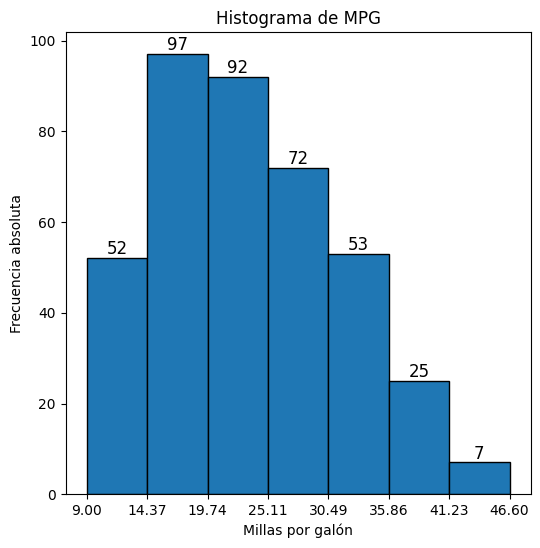

In [38]:
# Crear la instancia del gráfico
fig, ax = plt.subplots(figsize=(6,6))
# Dibujar el histograma y capturar los datos generados
# Bins -> número de intervalos
valores, limites, contenedor = ax.hist(variable, bins =7 , color = 'C0', edgecolor = 'black')
# Generar las etiquetas para el eje x utilizando los límites
plt.xticks(limites)
# Ciclos para los rótulos de las columnas
for p in ax.patches:
    ax.text(p.get_x()+p.get_width() / 2, p.get_height(), '%d' %int(p.get_height()), fontsize =12, color = 'black', ha = 'center', va = 'bottom')
plt.title('Histograma de MPG')
plt.xlabel('Millas por galón')
plt.ylabel('Frecuencia absoluta')
plt.show()

##### b. Gráfico de líneas para el % acumulado

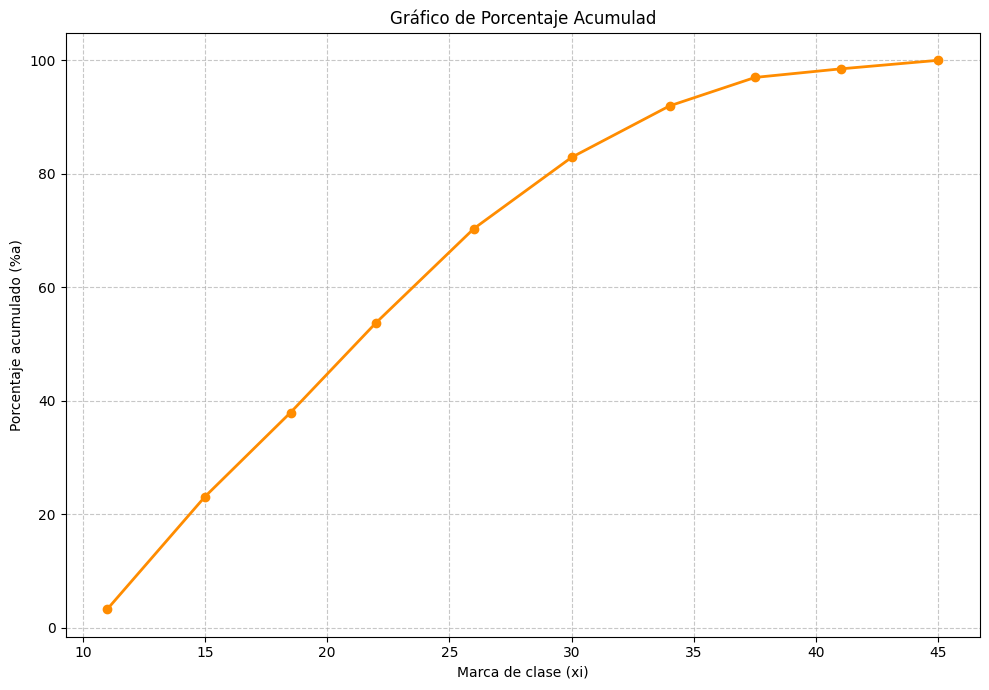

In [39]:

fig, axes = plt.subplots(figsize=(10,7))
axes.plot(tabla["xi"],tabla["%a"],marker="o",color="darkorange",linewidth=2,linestyle="-")
axes.set_title("Gráfico de Porcentaje Acumulad")
axes.set_xlabel("Marca de clase (xi)")
axes.set_ylabel("Porcentaje acumulado (%a)")
axes.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

#### 7. Interpretación de resultados

La varible estudiada mpg (millas por galón) mide el rendimiento de combustible y su eficiencia energética en vehículos, se expresa cuantitativamente en la distancia recorrida por cada galón consumido. 
En cuanto a las medidas de tendencia central, la media aritmética resultante es de **23.51 mpg** y la mediana es de **23 mpg**. La cercanía entre ambos valores muestra una distribución relativamente 
centrada, aunque la ligera disparidad donde la media supera a la mediana refleja una leve asimetría positiva, producida por grupo reducido de automóviles con eficiencias muy altas.

Al evaluar la dispersión de los datos, encontramos una desviación estándar de **7.82 mpg** y un coeficiente de variación del **33.24%**. Este porcentaje es una variabilidad moderada-alta en la muestra, 
lo que significa que el consumo de combustible es muy distinto entre los modelos de vehículos analizados.

A través de la distribución de frecuencias agrupadas en 10 intervalos de amplitud 3.8, observamos que la mayor concentración de datos ocurre en el segundo intervalo, es decir, el rango de **[13, 17) mpg**, 
acumulando un total de **79 vehículos**, lo cual equivale al **19.6%** de toda la muestra. Al analizar las frecuencias acumuladas, el valor de $f_a$ en este mismo intervalo alcanza un acumulado de **165 vehículos**. 
Esto indica que **165 autos (el 41.46%)** registran un rendimiento inferior a 20 millas por galón, evidenciando que casi más del 40% del dataset está compuesto por vehículos de alto consumo de combustible.

En conclusión, la muestra analizada refleja una marcada preponderancia de automóviles con rendimientos bajos a moderados, propios de motores de mayor cilindrada, mientras que los vehículos altamente eficientes (superiores a 35 mpg) representan una clara minoría dentro del estudio. 

#### Preguntas de reflexión

¿Por qué es necesario agrupar datos en intervalos cuando el tamaño de la muestra es grande?
-> Es necesario porque de lo contrario se generarían tablas extremadamente extensas, poco manejables y difíciles de interpretar.
    
¿Qué diferencia existe entre frecuencia absoluta y frecuencia relativa?
-> La frecuencia absoluta es el número exacto de observaciones que pertenecen a un intervalo específico, mientras que la específica mide el porcentaje que representa ese grupo sobre el total de la muestra.

¿Por qué la media agrupada no coincide exactamente con la media original?
-> No coincide porque al agrupar, asumimos que todos los datos contenidos en un untervalo se ubican en el punto medio, por lo que se pierde el valor individual exacto.

¿Qué información aporta la ojiva (gráfico de líneas sobre el porcentaje acumulado) que no aporta el histograma?
-> El histograma muestra cómo se distribuyen los datos intervalo por intervalo, mientras que la ojiva grafica el porcentaje acumulado. Así visualizamos fácilmente qué porcentaje de la muestra se encuentra por debajo o por encima de cierto valor, facilitando la estimación de percentiles y cuartiles. 

Si tuviera que comparar dos modelos de autos (p. ej., 4 vs 8 cilindros), ¿cómo usaría las tablas de frecuencia para hacerlo?
Construiría una tabla de frecuencias relativas para cada categoría (una para 4 y otra para 8 cilindros). Al comparar las frecuencias relativas de cada intervalo, se puede contrastar el comportamiento de ambos grupos para observar qué grupo desplaza su distribución hacia rangos de mayor o menor rendimiento de combustible.